In [1]:
import os
# import gc
import asyncio
from typing import Type

from connector.monitor import Monitor
from connector.connector import BaseConnector
from connector.binance.binance_perp import BinancePerp
from connector.binance.binance_spot import BinanceSpot

print(f"PID: {os.getpid()}")
connector_type_list: list[Type[BaseConnector]] = [BinancePerp, BinanceSpot]
m = Monitor(connector_type_list=connector_type_list)
#gc.disable()
task = asyncio.create_task(m.run())


PID: 3945216


In [8]:
task.cancel()  # отправляем CancelledError в run()
await task 

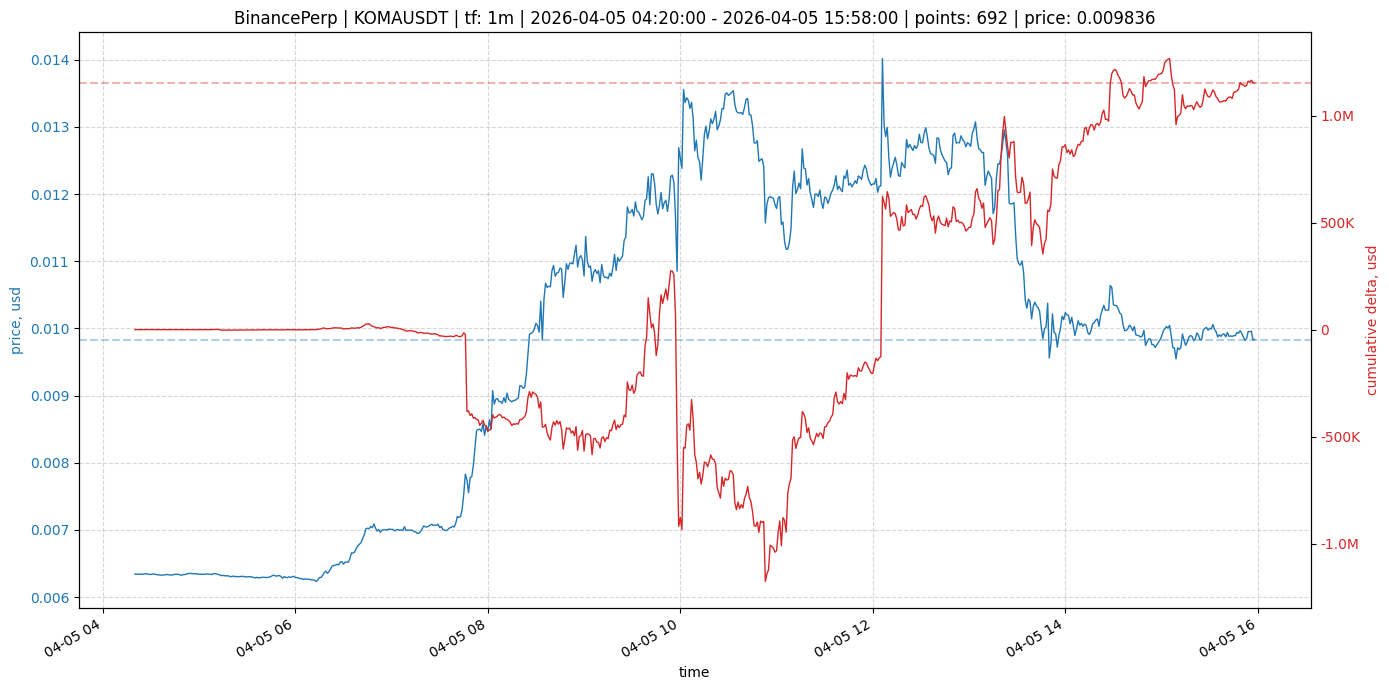

KOMAUSDT: буфер пуст


In [14]:
import importlib
import connector.visualization as visual
importlib.reload(visual)

symbol = "KOMAUSDT"
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinancePerp], "1m")
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinanceSpot], "1m")

In [206]:
import importlib
import connector.utils_io as utils_io
importlib.reload(utils_io)

await utils_io.save_all_trade_data(m.connectors)

In [23]:
import pandas as pd
from typing import Any
rows: list[dict[str, Any]] = []
for symbol, trade_container in m.connectors[BinancePerp].trade_service.containers.items():
    idx = trade_container.public_trades_1m.idx
    wrapped = trade_container.public_trades_1m.wrapped
    size = trade_container.public_trades_1m.size
    price_close = trade_container.public_trades_1m.prices[idx]
    price_open = trade_container.public_trades_1m.prices[(idx + 1) % size if wrapped else 0]
    rows.append({"symbol": symbol, "price_open": price_open, "price_close": price_close, "delta": round((price_close/price_open-1)*100, 1)})

df = pd.DataFrame(rows)
df.sort_values("delta", ascending=False)


,symbol,price_open,price_close,delta
251,BULLAUSDT,0.005844,0.009125,56.1
449,KOMAUSDT,0.006346,0.009493,49.6
226,MMTUSDT,0.111800,0.141000,26.1
217,AIOTUSDT,0.027030,0.033860,25.3
4,BSBUSDT,0.233430,0.288290,23.5
...,...,...,...,...
189,HEMIUSDT,0.008758,0.007506,-14.3
174,NOMUSDT,0.006278,0.005346,-14.8
115,THEUSDT,0.121200,0.102400,-15.5
210,BRUSDT,0.183670,0.132570,-27.8


['2026-04-05T16:45:00.669']
[0.57616]
[0.57613]
[30139.]
[1.00463333e+09]
10000


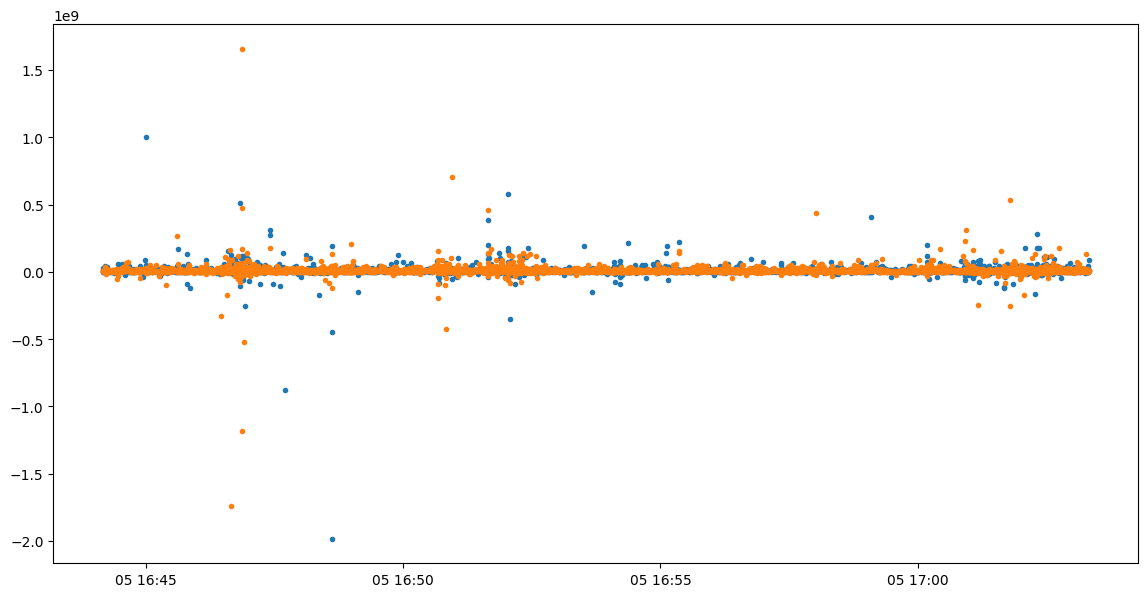

In [26]:
symbol = "SIRENUSDT"
trades = m.connectors[BinancePerp].trade_service[symbol].public_side_trades

end = len(trades)

t = trades.timestamps[: end].astype("datetime64[ms]")
buy_ids = (trades.volumes[: end] > 0) & (trades.close_prices[: end] != trades.open_prices[: end])
sell_ids = (trades.volumes[: end] < 0) & (trades.close_prices[: end] != trades.open_prices[: end])
v_dp_buy = trades.volumes[buy_ids] / (trades.close_prices[buy_ids] - trades.open_prices[buy_ids])
v_dp_sell = trades.volumes[sell_ids] / (trades.close_prices[sell_ids] - trades.open_prices[sell_ids])

print(t[buy_ids][v_dp_buy > 1e9])
print(trades.close_prices[buy_ids][v_dp_buy > 1e9])
print(trades.open_prices[buy_ids][v_dp_buy > 1e9])
print(trades.volumes[buy_ids][v_dp_buy > 1e9])
print(v_dp_buy[v_dp_buy > 1e9])
print(end)
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

plt.scatter(t[buy_ids], v_dp_buy, marker='.')

_=plt.scatter(t[sell_ids], v_dp_sell, marker='.')

In [18]:
trades.close_prices[v_dp_buy > 1e10]

NameError: name 'trades' is not defined

In [8]:
m.connectors[BinancePerp].trade_service["BTCUSDT"].public_side_trades.open_prices[0]

np.float64(67100.1)

In [11]:
m.connectors[BinancePerp].trade_service.containers.items()

dict_items([('APTUSDT', <connector.public_trade_service.TradesContainer object at 0x77e3c4183950>), ('1000CATUSDT', <connector.public_trade_service.TradesContainer object at 0x77e3c43e6dd0>), ('SOPHUSDT', <connector.public_trade_service.TradesContainer object at 0x77e3c415cfd0>), ('SAGAUSDT', <connector.public_trade_service.TradesContainer object at 0x77e3c4183750>), ('0GUSDT', <connector.public_trade_service.TradesContainer object at 0x77e3c4183a90>), ('DOLOUSDT', <connector.public_trade_service.TradesContainer object at 0x77e3c4180d90>), ('GIGGLEUSDT', <connector.public_trade_service.TradesContainer object at 0x77e393669110>), ('HUMAUSDT', <connector.public_trade_service.TradesContainer object at 0x77e393669150>), ('TIAUSDT', <connector.public_trade_service.TradesContainer object at 0x77e393669190>), ('SAHARAUSDT', <connector.public_trade_service.TradesContainer object at 0x77e3936691d0>), ('LAYERUSDT', <connector.public_trade_service.TradesContainer object at 0x77e393669210>), ('DEN

In [ ]:
perp_symbols = set(instrument.unified_symbol for instrument in m.connectors[BinancePerp].instrument_manager.values())
spot_symbols = set(instrument.unified_symbol for instrument in m.connectors[BinanceSpot].instrument_manager.values())
unified_symbols = perp_symbols & spot_symbols
len(perp_symbols), len(spot_symbols), len(unified_symbols)

(542, 439, 371)

In [ ]:
m.connectors[BinancePerp].orderbook_service["BTCUSDT"].message

''

In [ ]:
m.connectors[BinanceSpot].orderbook_service["BTCUSDT"].message

'{"u":91193085088,"s":"BTCUSDT","b":"67026.03000000","B":"2.42203000","a":"67026.04000000","A":"0.24394000"}'

In [ ]:
m.connectors[BinanceSpot].trade_service["BTCUSDT"].public_trades

68300.37

In [ ]:
m.connectors[BinanceSpot].trade_service["BTCUSDT"].public_trades_1s

In [4]:
min_delay = 0

In [ ]:
exchange_symbol = "BTCUSDT"
perp_ask_price: float = m.connectors[BinancePerp].orderbook_service[exchange_symbol].best_ask
perp_bid_price: float = m.connectors[BinancePerp].orderbook_service[exchange_symbol].best_bid
spot_bid_price: float = m.connectors[BinanceSpot].orderbook_service[exchange_symbol].best_bid
spot_ask_price: float = m.connectors[BinanceSpot].orderbook_service[exchange_symbol].best_ask
delay = int(time.time()*1000 - m.connectors[BinanceSpot].orderbook_service[exchange_symbol].transaction_ts_ms)
delay2 = int(time.time()*1000 - m.connectors[BinancePerp].trade_service[exchange_symbol][-1].transaction_ts_ms)
if min_delay>delay:
    min_delay=delay
perp_ask_price, perp_bid_price, spot_bid_price, spot_ask_price, delay-min_delay, delay2-min_delay, min_delay

(0, 0, 0, 0, 76, 65, -1063)

In [ ]:
m.connectors[BinancePerp].orderbook_service.text_data.qsize()

0